# Tehran Road Network and University Accessibility

## Overview
In this project you are able to choose two places on the map and it will tell you the shortest 
road map to it.
for next part of the project you get a hexbin map that tell you over all how much university accross the city are accessable 
and after that the top universitys are shown
and lastly you get a heatmap that show the overall map of tehran base on the distance to the closest university

## Used Technologies, Packages and Libraries
**pyrosm**: For the map analysis </br>
**pandas** and **numpy**: For fast and organized way to handel map data </br>
**geopandas** and **shapely**: For better repressentation of geo data </br>
**ipyleaflet**: To show the map </br>
**networkx**: To use dijkstra algrorithm for finding the shortest network road </br>
**scipy**: for the cKDTree algorithm to find the closest node

### Explain the below code:
The get_data function get the Tehran.pbf them we make an osm using the OpenStreetMap PBF reader object using the OSM function. </br>
Then we use the this OSM to get the network graph and then we make a Graph using nx for the shortest path


In [5]:
from pyrosm import get_data,OSM
import geopandas as gpd
import pandas as pd
from ipyleaflet import Map, Marker,Polyline, AwesomeIcon, Popup
from ipywidgets import HTML
import networkx as nx
import numpy as np
from shapely import Point
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.interpolate import griddata
from collections import defaultdict


fp = get_data("Tehran", update=True)
# fp = get_data("Tehran")
osm = OSM(fp)

nodes,edges = osm.get_network(network_type="driving", nodes= True)


Graph = nx.from_pandas_edgelist(
    edges,
    source = 'u',
    target = 'v',
    edge_attr=['length'],
    create_using= nx.DiGraph()
)


Downloaded Protobuf data 'Tehran.osm.pbf' (8.82 MB) to:
'/tmp/pyrosm/Tehran.osm.pbf'


### Explain each function
**closest_node**: Return the closest node </br>
**calc_shortest_node_to_buildings**: Add the *closest_node_id* column using cKDTree algorithm </br>
**draw_route**: Using the shortest nx it find the shortest from two nodes </br>
**remove_route**: Remove the route(if the one the two mark get removed) </br>
**mark_university_by_color**: Mark top accessable university

In [6]:

def closest_node(location: tuple[float,float], crs= 4326) -> list[tuple[float,float],int]:

    nodes_in_utm = nodes.to_crs(32639)
    point_gdf = gpd.GeoDataFrame(geometry=[Point(location[::-1])], crs=f"EPSG:{crs}").to_crs(epsg=32639)
    point = point_gdf.geometry.iloc[0]

    nodes_in_utm['distance'] = nodes_in_utm.geometry.distance(point)
    index_min = nodes_in_utm['distance'].idxmin()

    lat = nodes.iloc[index_min]['lat']
    lon = nodes.iloc[index_min]['lon']


    return [(lat,lon),nodes.iloc[index_min]['id']]


def calc_shortest_node_to_buildings(buildings, nodes):

    buildings_utm = buildings.to_crs(epsg=32639)
    nodes_utm = nodes.to_crs(epsg=32639)

    centroids = buildings_utm.geometry.centroid

    building_coords = np.column_stack((centroids.x, centroids.y))
    node_coords = np.column_stack((nodes_utm.geometry.x, nodes_utm.geometry.y))

    tree = cKDTree(node_coords)

    _, indices = tree.query(building_coords, k=1)

    closest_node_ids = nodes_utm.iloc[indices]['id'].values

    buildings['nearest_node_id'] = closest_node_ids


def draw_route(from_node: tuple[float,float], to_node: tuple[float,float]) -> Polyline :

    try:
        path = nx.shortest_path(Graph, source=from_node, target=to_node, weight='length')
    except nx.NetworkXNoPath:
        print(f"No path exists between {from_node} and {to_node}")
        return None
    except nx.NodeNotFound as e:
        print(f"Node not found: {e}")
        return None

    path_coords = nodes.set_index("id").loc[path][['lat','lon']].values.tolist()
    # path_coords = nodes[nodes['id'].isin(path)][['lat','lon']].values.tolist()

    route = Polyline(
        locations = path_coords,
        fill=False
    )

    map.add(route)
    return route

def remove_route(route: Polyline):

    def callback(_ = None, **kwargs) -> None :
        if route in map.layers:
            map.remove(route)

    return callback


def mark_university_by_color(universities_id: list[int], universities:gpd.GeoDataFrame,map: Map,color:str) -> None:

    for university_id in universities_id:
        chosen_uni = universities[universities.id == university_id]

        uni_location =chosen_uni.geometry.centroid.values[0]

        name = chosen_uni['name'].values

        if(None in name):
            name = "No Available Name"
        else:
            name = name[0]

        popup = Popup(
            location=[uni_location.y,uni_location.x],
            child=HTML(f"<b>{name}</b>"),
            close_button=False,
            auto_close=False
        )

        uni_marker = Marker(
            location= [uni_location.y,uni_location.x],
            draggable = False,
            popup= popup,
            icon=AwesomeIcon(
                name='university',      
                marker_color=color,   
                icon_color='white',              
            )
        )

        map.add(uni_marker)

In [7]:
center = (35.6892, 51.3890)
map: Map = Map(center= center, zoom= 12)

### Explain the code below

I store the two markers in the markers and thir ids in the markers_nodes_ids. </br>
I added the add_marker function to handel the click event on the map to which it add a marker to the closest node to where the user clicked and if the two markers exsist it call draw_route to draw the shortest path. </br>
And a remvoe_marker which generate a function that which handel removing the marker when it cliked again

In [8]:

markers: dict[str, Marker] = {
    "start": None,
    "end": None
}

markers_nodes_ids: dict[str,int] = {
    "start": None,
    "end": None
}

def remove_marker(marker):
    def callback(_ = None, **kwargs) -> None :
        map.remove(markers[marker])
        markers[marker] = None
        markers_nodes_ids[marker] = None
    
    return callback

def add_marker(**kwargs) -> None:

    if kwargs.get("type") == "click":

        location: tuple[float,float] = kwargs.get("coordinates")
 
        location,id = closest_node(location)

        if (not markers["start"] or not markers['end']):
            marker: Marker = Marker(location= location, draggable = False)
            if(markers['start'] is None):
                markers['start'] = marker 
                markers_nodes_ids['start'] = id
                marker.on_click(remove_marker("start"))
            else:
                markers['end'] = marker
                markers_nodes_ids['end'] = id
                marker.on_click(remove_marker("end"))

            map.add(marker)

            if(markers['start'] and markers['end']):
                route = draw_route(markers_nodes_ids['start'], markers_nodes_ids['end'])


                if route is None:
                    map.remove(markers["start"])
                    map.remove(markers["end"])
                    markers["start"] = None
                    markers["end"] = None
                    markers_nodes_ids["start"] = None
                    markers_nodes_ids["end"] = None
                    return


                markers['start'].on_click(remove_route(route))
                markers['end'].on_click(remove_route(route))

        
map.on_interaction(add_marker)

map


Map(center=[35.6892, 51.389], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

### Explain the code below

The get_pois get the point of interest the with the ```custom_filter={"amenity": ["university"]}``` it can find all the universities

In [9]:
buildings = osm.get_buildings()
universities = osm.get_pois(custom_filter={"amenity": ["university"]})

### Explain the code below

Add the closest_node_id to both buildings and universities

In [10]:
calc_shortest_node_to_buildings(buildings,nodes)
calc_shortest_node_to_buildings(universities,nodes)

### Explain the code below

I used nx.multi_source_dijestra to find the closest uni_node to each building then i used that node to find closest university by mapping on the buildings

In [11]:
uni_nodes: list[int] = universities['nearest_node_id'].tolist()

distances, paths = nx.multi_source_dijkstra(Graph, sources=uni_nodes, weight='length')

buildings['nearest_uni_node'] = buildings['nearest_node_id'].map(
    lambda nid: paths[nid][0] if nid in paths else np.nan
)

buildings['dist_to_uni'] = buildings['nearest_node_id'].map(
    lambda nid: distances.get(nid, np.inf)
)

uni_node_to_id = pd.Series(universities.id.values, index=universities.nearest_node_id).to_dict()
buildings['nearest_university_id'] = buildings['nearest_uni_node'].map(uni_node_to_id)


### Explain the code below

The idea is to group the buildings which have the same nearest_university_id
then treat them all as the university

In [12]:

# uni_geometry_lookup = universities.set_index('id')['geometry'].to_dict()

# grouped_locations = defaultdict(list)

# for _, row in buildings.iterrows():
#     university_id = row['nearest_university_id']
    
#     point = uni_geometry_lookup.get(university_id, None)
    
#     if point is not None:
#         grouped_locations[university_id].append(point.centroid)

# locations = list(grouped_locations.values())

In [13]:
buildings_merged_with_university = buildings.merge(
    universities[['id', 'geometry']],
    how='left',
    left_on='nearest_university_id',
    right_on='id',
    suffixes=('', '_university')
)

buildings_merged_with_university['university_centroid'] = buildings_merged_with_university['geometry_university'].centroid

grouped_locations = buildings_merged_with_university.groupby('nearest_university_id')['university_centroid'].apply(list)

locations = grouped_locations.tolist()


/tmp/ipykernel_1272/1123400014.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_merged_with_university['university_centroid'] = buildings_merged_with_university['geometry_university'].centroid


### Explain the code below

Draw a hexbin using the density of the building close to each university

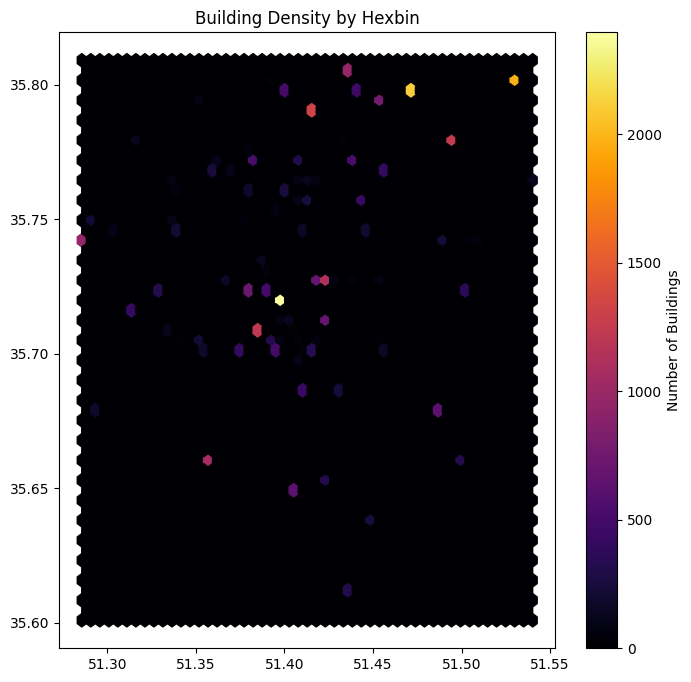

In [14]:

x = [point.x for group in locations for point in group]
y = [point.y for group in locations for point in group]

plt.figure(figsize=(8,8))
plt.hexbin(x, y, gridsize=50, cmap='inferno')
plt.colorbar(label='Number of Buildings')
plt.title("Building Density by Hexbin")
plt.show()


### Explain the code below

Mark the top universities which have more than 2000 building close to it by the color orange. </br>
Mark the mid top universities which have between 1500 to 2000 building close to by the color red. </br>
Mark the low top universities which have between 1000 to 1500 building close to by the color purple

In [15]:

top_universitys_ids = buildings.groupby('nearest_university_id').size().where(buildings.groupby('nearest_university_id').size() > 2000).dropna().index.tolist()
mid_top_universitys_ids = buildings.groupby('nearest_university_id').size().where((buildings.groupby('nearest_university_id').size()<= 2000) & (buildings.groupby('nearest_university_id').size() > 1500)).dropna().index.tolist()
low_top_universitys_ids = buildings.groupby('nearest_university_id').size().where((buildings.groupby('nearest_university_id').size()<= 1500) & (buildings.groupby('nearest_university_id').size() > 1000)).dropna().index.tolist()

mark_university_by_color(top_universitys_ids,universities,map, color = 'orange')
mark_university_by_color(mid_top_universitys_ids,universities,map, color = 'red')
mark_university_by_color(low_top_universitys_ids,universities,map, color = 'purple')

map

/tmp/ipykernel_1272/1042894427.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  uni_location =chosen_uni.geometry.centroid.values[0]
/tmp/ipykernel_1272/1042894427.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  uni_location =chosen_uni.geometry.centroid.values[0]
/tmp/ipykernel_1272/1042894427.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  uni_location =chosen_uni.geometry.centroid.values[0]
/tmp/ipykernel_1272/1042894427.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-proje

Map(bottom=413078.0, center=[35.6892, 51.389], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoo…

### Explain the code below

I start with getting the x, y of the building and the distance to the closest university as z. <br />
Then I make a grid using linespace fand meshgrid then i put the value z in the column in (xi,yi) that represent (x,y)
then i make a this zi and make an image using imshow and lastly I show it 

/tmp/ipykernel_1272/958125423.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x = buildings.geometry.centroid.x.values
/tmp/ipykernel_1272/958125423.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y = buildings.geometry.centroid.y.values


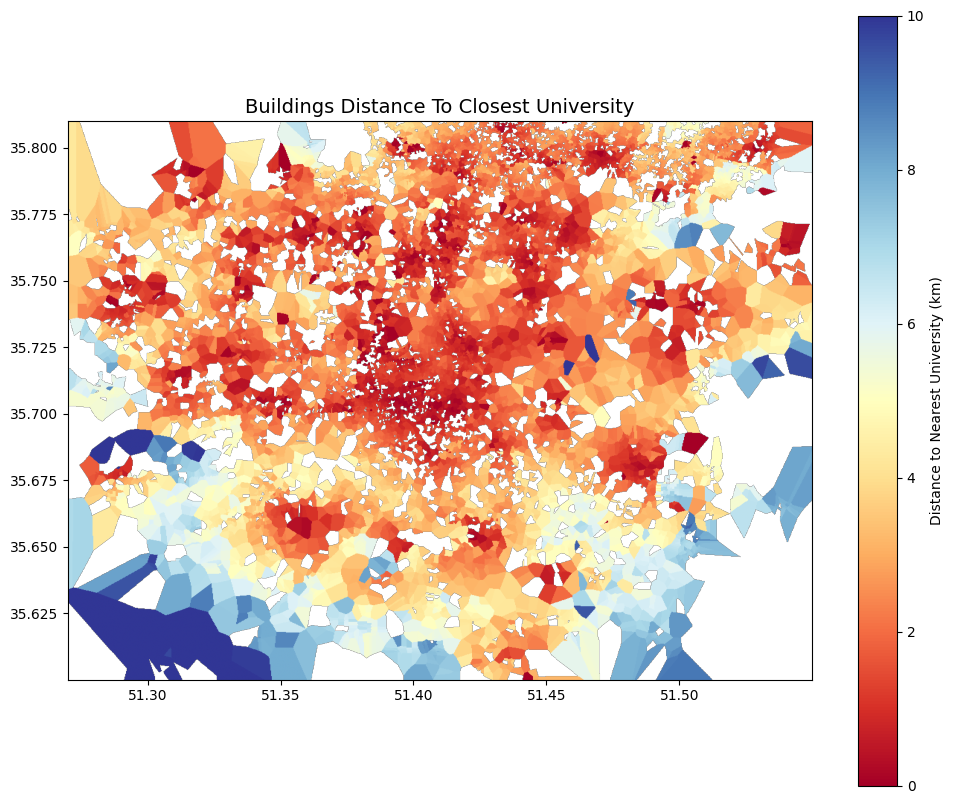

In [ ]:

x = buildings.geometry.centroid.x.values 
y = buildings.geometry.centroid.y.values
z = buildings['dist_to_uni'].values /1000 


xi = np.linspace(x.min(), x.max(), 1000)
yi = np.linspace(y.min(), y.max(), 1000)
xi, yi = np.meshgrid(xi, yi)

# zi = griddata((x, y), z, (xi, yi), method='linear')
zi = griddata((x, y), z, (xi, yi), method='nearest')
plt.style.use("dark_background")
plt.figure(figsize=(12, 10))

img = plt.imshow(
    zi, 
    origin='lower', 
    cmap='RdYlBu',   
    extent=(x.min(), x.max(), y.min(), y.max()),
    vmax=10
)

plt.colorbar(img, label='Distance to Nearest University (km)')

plt.title('Buildings Distance To Closest University', fontsize=14)
plt.show()
